Cesar Pinto
Aldair Gonzalez
Sumy ricarte
Fernando Montenegro
Yhael Cardemas

#**Introduction to the Case Study**

This case study focuses on a resource optimization problem within a fax order processing center. The fundamental business objective is to determine the minimum staffing level (the lowest number of Entry Agents and Specialists) required for two distinct shifts (before and after 12 PM) in order to minimize operational costs while strictly achieving the required service-level metrics.

Discrete-event simulation is the tool used to test various staffing policies and find the optimal balance between cost efficiency and service quality.

For a staffing policy to be deemed acceptable, it must strictly comply with the following service requirements (SLAs), where the time is measured from the fax's arrival to its completion:

####Simple faxes:
Compliance requierement(SLA): 96%

Time limit: Whitin 10min arrival

####Specialist faxes:
Compliance requierement(SLA): 80%

Time limit: Within 10min of arrival(completed by both agents)

Data and information provided:
The simulation model is built upon the following probability distributions and operational parameters:

A. Schedule and Shifts

Operating Hours: The center receives faxes from 8:00 AM to 4:00 PM.

Staffing Change: The staffing level can be adjusted at 12:00 PM (noon).

End-of-Day Rule: The staff does not leave until all faxes that arrived before 4 PM have been processed.

B. Arrival Distribution (Demand)

Fax arrivals are modeled as a Nonstationary Poisson Process, meaning the arrival rate ($\lambda$) varies hourly throughout the day.



TIME                

8am - 9am             

9am - 10am            

10am -11am            

11am -12pm            

12pm - 1pm            

1pm - 2pm             

2pm - 3pm             

3pm - 4pm             

Rate(faxes/minute):

4,37

6.24

5.29

2.97

2.03

2.79

2.36

1.04

C. Service Time Distribution (Resources)

Entry Agents (Regular):

Service Time: Normally Distributed with a mean of 2.5 minutes and a standard deviation ($\sigma$) of 1 minute.

Specialists:

Proportion: Approximately 20% of faxes require a Specialist after the Entry Agent.

Service Time: Normally Distributed with a mean of 4.0 minutes and a standard deviation ($\sigma$) of 1 minute.

D. Initial Staffing Policy (Base Case Test)

The exercise suggests testing the following initial scenario, which will serve as the first simulation replication:

####Entry agents:
AM Shift: 15 agents

PM Shift: 9 agents
####Specialists:
AM Shift: 6 specialists

PM Shift: 3 specialists




##**Preparing the simulation**



In [ ]:
!pip install simpy

In [ ]:
import simpy
import random
import math
import matplotlib.pyplot as plt
import numpy as np
import warnings
import seaborn as sns

**class f ⛲:** this class contains our global parameters as the period in this case 8 as the wroking-hours , our specialist and classic agent



mean and std

**The main staff that we should optimizate ❤**

the arrivals times from 4.37 - 1.04

the the probability of needing an specialist

basically this class aim to set the enviroment work enviroment

In [ ]:
class F:
  """work enviroment"""

  maxTime=100 #time is converted to hours 3/4
  seedval=1234 #seed
  period=60.0  # per hour
  nperiods= 8 # 8 wori¿king hours

  #classic agent
  meanRegular=2.5/period
  stdregular= math.sqrt(1.0)/period #period to  set to hours scale

  #special
  meanSpecial=4.0/period
  stdSpecial= math.sqrt(1.0)/period

  tPMshitfchangue=4.0 # at the 4th period 12 pm

  #---------------------------------------------------------------------
  #staff project goal
  numAgents=21
  numAgentsPM=10
  numSpecialist=7
  numSpecialistPM=3

  aRate = [4.37, 6.24, 5.29, 2.97, 2.03, 2.79, 2.36, 1.04] # faxes/minute
  aRateperhour = [r * 60.0 for r in aRate] #set the rate to hours each hour
  maxRate = 6.24

    # meanTBA (Time Between Arrivals) is 1/lambda. Calculated using maxRate initially.
  meanTBA = 1.0 / (maxRate * period)

  pSpecial = 0.20     # Probability of needing a Specialist



In [ ]:
class Monitor:
    """Class to track observations (like wait times), replacing the old SimPy 2.x Monitor."""
    # Class docstring explaining purpose
    def __init__(self, name=""):
        # Initialize the Monitor with an optional name
        self.name = name
        # List to store the observed data values
        self.data = []

    def observe(self, value):
        # Record a new observation value
        self.data.append(value)

    def count(self):
        # Returns the total number of observations recorded
        return len(self.data)

    def mean(self):
        # Calculates the mean (average) of the recorded observations
        # Returns 0.0 if no data is present
        return np.mean(self.data) if self.data else 0.0

    def yseries(self):
        # Returns the raw list of observed data values
        return self.data

Cada resource actua como un semaforo por el funcionamiento interno
compuesto de dos queues

queue de entrada o request y la de get o realise  

por consiguiente cada agente solicitará un proceso y entrara a la fila   se usa el operador yield ya que este "holdea" lo que este siendo procesado

el operador time out es el tiempo de espera del proceso siendo asi que toma la función random variative para simular el tiempo

simulamos el proceso de FIFO de los faxes

usamos random.normalvariative(mu,std) esto determina que nos arrojé un valor de la distribución de request ya sean especiales o normales con su respectiva distribución de probabilidad y desviación estandar

In [ ]:
def fax_proceso(env, name, arrive_time, agents, specialagents, Regularwait, Specialistwait):
    """ fax_proceso function, was cut off in the original code, completed here """
    # Request a regular agent resource
    with agents.request() as req_agent:
        # Wait until a regular agent is available
        yield req_agent

        # Determine the regular service time using a normal distribution
        tis=random.normalvariate(F.meanRegular,F.stdregular)
        # Ensure service time is not negative
        if tis<0: tis =0.0
        # Simulate the regular service time
        yield env.timeout(tis)

        # Check if the fax needs a specialist (based on probability F.pSpecial)
        if random.random() < F.pSpecial:
            # Request a specialist agent resource
            with specialagents.request() as req_special:
                # Wait until a specialist is available
                yield req_special

                # Determine the specialist service time using a normal distribution
                tspecial=random.normalvariate(F.meanSpecial,F.stdSpecial)
                # Ensure service time is not negative
                if tspecial<0: tspecial=0.0
                # Simulate the specialist service time
                yield env.timeout(tspecial)

                # Calculate total time spent (finish time - arrival time)
                finished=env.now - arrive_time
                # Record the wait/service time in the specialist monitor
                Specialistwait.observe(finished)
        else:
            # If no specialist is needed, calculate and record regular service time
            # Calculate total time spent (finish time - arrival time)
            finished=env.now - arrive_time
            # Record the wait/service time in the regular monitor
            Regularwait.observe(finished)


In [ ]:
import random # Assumed import for random functions
# Assumed fax_proceso is defined elsewhere

def source_proceso(env, agents, specialagents, Regularwait, Specialistwait):
    """Generates faxes based on the time-varying arrival rate."""
    # Counter for the number of faxes generated
    i = 0
    # Loop condition: continue generating faxes until the simulation time limit (F.nperiods) is reached,
    # and the mean inter-arrival time is positive.
    while env.now < F.nperiods and F.meanTBA > 0:
        # Determine time until next arrival using exponential distribution
        time_between_arrivals = random.expovariate(1.0 / F.meanTBA)
        # Wait/Advance simulation time until the next fax arrival
        yield env.timeout(time_between_arrivals)

        # Record the current time as the arrival time of the new fax
        arrive_time = env.now
        # Start a new process (instance of fax_proceso) for the newly arrived fax
        env.process(fax_proceso(env, f"Fax{i:02d}", arrive_time, agents, specialagents, Regularwait, Specialistwait))
        # Increment the fax counter
        i += 1

In [ ]:
def arrival_rate_proceso(env, aRateperhour):
    """Updates the arrival rate (meanTBA) every hour."""
    # Iterate through the list of arrival rates provided (one for each hour)
    for rate_per_hour in aRateperhour:
        # Check if the hourly rate is positive
        if rate_per_hour > 0:
            # Calculate the Mean Time Between Arrivals (meanTBA) as 1 / rate
            F.meanTBA = 1.0 / rate_per_hour
        else:
            # If rate is zero or negative, set meanTBA to 0, stopping arrivals
            F.meanTBA = 0.0

        # Advance the simulation time by 1.0 unit (assuming 1.0 represents one hour)
        yield env.timeout(1.0) # 1.0 hours

In [ ]:
def agent_off_proceso(env, agent_resource):
    """Process to remove an agent/specialist."""

    # Calculate the remaining time until the end of the simulation/shift (F.maxTime)
    tremain = F.maxTime - env.now + 1.0

    # Request the agent resource with a very high priority (100)
    # This ensures the process gets the agent immediately or as soon as it's free.
    with agent_resource.request(priority=100) as req:
        # Wait until the high-priority request is granted
        yield req
        # Hold the resource for the remaining time, effectively taking the agent offline
        yield env.timeout(tremain)

In [ ]:
# Assumed agent_off_proceso is defined elsewhere

def second_shift_proceso(env, tPMshitfchangue, agents, specialagents):
    """Triggers the change in staffing levels at noon."""

    # Wait until the designated time for the shift change (e.g., 12:00 PM)
    yield env.timeout(tPMshitfchangue)

    # Calculate the number of regular agents to be taken offline
    reduceagents = F.numAgents - F.numAgentsPM
    # Calculate the number of specialist agents to be taken offline
    reducespecial = F.numSpecialist - F.numSpecialistPM

    # Iterate and start a process to take the required number of regular agents offline
    for i in range(reduceagents):
        # Start the agent_off_proceso for each regular agent to be removed
        env.process(agent_off_proceso(env, agents))

    # Iterate and start a process to take the required number of specialist agents offline
    for j in range(reducespecial):
        # Start the agent_off_proceso for each specialist agent to be removed
        env.process(agent_off_proceso(env, specialagents))

SIMULATION ENGINE 🫩​

In [ ]:
class FaxCenterSim:
    """The main simulation driver."""

    def run(self, aseed):
        random.seed(aseed)
        self.env = simpy.Environment()
#definir los recursos de los agentes para la simulación mediante el enviroment de simpy
        #cambio en priority resource comentar función de simpyu
        self.agents = simpy.PriorityResource(self.env, capacity=F.numAgents)  #importante cambio en el priority por la version de simpy esto no anula la funcionalidad de FIFO
        self.specialagents = simpy.PriorityResource(self.env, capacity=F.numSpecialist) #

        self.Regularwait = Monitor(name="Regular time")
        self.Specialistwait = Monitor(name="Special time")
#seting de los procesos request y sus comportamientos como el segundo cambio
        self.env.process(arrival_rate_proceso(self.env, F.aRateperhour))
        self.env.process(source_proceso(self.env, self.agents, self.specialagents, self.Regularwait, self.Specialistwait))
        self.env.process(second_shift_proceso(self.env, F.tPMshitfchangue, self.agents, self.specialagents))

        self.env.run(until=F.maxTime)  # definiendo el tiempo maximo del enviroment

    def reporting(self):
        """Calculates the service level requirements."""

        time_limit = 1.0 / 6.0 # 10 minutes in hours

        # simple faxes
        regularcount = self.Regularwait.count()
        regularwait = self.Regularwait.mean()

        if regularcount > 0:
            regular10min = sum([1.0 if waittime < time_limit else 0.0 for waittime in self.Regularwait.yseries()])
            fractionregular10min = regular10min / regularcount
        else:
            fractionregular10min = 0.0

        #special faxes
        specialcount = self.Specialistwait.count()
        specialwait = self.Specialistwait.mean()

        if specialcount > 0:
            special10min = sum([1.0 if waittime < time_limit else 0.0 for waittime in self.Specialistwait.yseries()])
            fractionspecial10min = special10min / specialcount
        else:
            fractionspecial10min = 0.0

        return [regularwait, specialwait, fractionregular10min, fractionspecial10min]



**Consideraciones importantes ✈ **
punto clave : 10 simulaciones eran insuficientes para tener datos acertados y
una representación propia de la media , los valores dados en la politica anterior , al aumentar el numero de simulaciones los valores bajaron pero se optimizó el número de agentes que era la problematica principal y se aumentaron los porcentajes en contraste con los valores de la politica anterior  :


Política de Personal: 15/9 Agentes, 6/3 Especialistas
Número de Replicaciones: 1000

Métricas (Media ± Desviación Estándar):
Tiempo Promedio de Proceso (Regulares): 0.2582 ± 0.0508 horas
Tiempo Promedio de Proceso (Especiales): 0.3317 ± 0.0553 horas
NIVELES DE SERVICIO:
Regulares (< 10 min) | Meta: 96%  | Logrado: 46.93% ± 7.05%
Especiales (< 10 min) | Meta: 80%  | Logrado: 32.52% ± 7.40%

In [ ]:
reps = 100
faxsimulation = []


for i in range(reps):
    # Restablece meanTBA para cada replicación
    F.meanTBA = 1.0 / (F.maxRate * F.period)

    faxsim = FaxCenterSim()
    faxsim.run(F.seedval + i)
    result = faxsim.reporting()
    faxsimulation.append(result)


faxsimulation = np.array(faxsimulation)
mean_results = np.mean(faxsimulation, axis=0)
std_results = np.std(faxsimulation, axis=0)



print(f"Política de Personal: {F.numAgents}/{F.numAgentsPM} Agentes, {F.numSpecialist}/{F.numSpecialistPM} Especialistas")
print(f"Número de Replicaciones: {reps}")

print("\nMétricas (Media ± Desviación Estándar):")
print(f"Tiempo Promedio de Proceso (Regulares): {mean_results[0]:.4f} ± {std_results[0]:.4f} horas")
print(f"Tiempo Promedio de Proceso (Especiales): {mean_results[1]:.4f} ± {std_results[1]:.4f} horas")

print("NIVELES DE SERVICIO:")
print(f"Regulares (< 10 min) | Meta: 96%  | Logrado: {mean_results[2]*100:.2f}% ± {std_results[2]*100:.2f}%")
print(f"Especiales (< 10 min) | Meta: 80%  | Logrado: {mean_results[3]*100:.2f}% ± {std_results[3]*100:.2f}%")



Política de Personal: 21/10 Agentes, 7/3 Especialistas
Número de Replicaciones: 100

Métricas (Media ± Desviación Estándar):
Tiempo Promedio de Proceso (Regulares): 0.0560 ± 0.0095 horas
Tiempo Promedio de Proceso (Especiales): 0.1263 ± 0.0108 horas
NIVELES DE SERVICIO:
Regulares (< 10 min) | Meta: 96%  | Logrado: 98.67% ± 3.37%
Especiales (< 10 min) | Meta: 80%  | Logrado: 87.60% ± 8.28%


Este gráfico de barras es crucial porque te permite evaluar el rendimiento promedio de tu política de personal frente a los objetivos de servicio. Matemáticamente, la altura de la barra es la Media $(\mu)$ de cientos o miles de faxes simulados. El elemento más importante son las Barras de Error, que representan la Desviación Estándar ($\sigma$) de las réplicas.

Analíticamente, esta desviación estándar mide la variabilidad del sistema: una barra de error corta indica que el rendimiento es consistente en diferentes días simulados, mientras que una barra larga sugiere que, bajo la misma política, tu nivel de servicio puede fluctuar drásticamente.El valor analítico reside en la comparación directa con la Línea de Meta.

**CONCLUSION:** Equilibrando costos y servicios con una política de staffing de  17/6 y 8/3 esta politica le hae justicia tanto a los requerimientos de los clientes de igual manera con los costos


<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3929016112.py:26: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title('Cumplimiento de Nivel de Servicio (SLR) - Media $\pm \sigma$', fontsize=16, fontweight='bold')


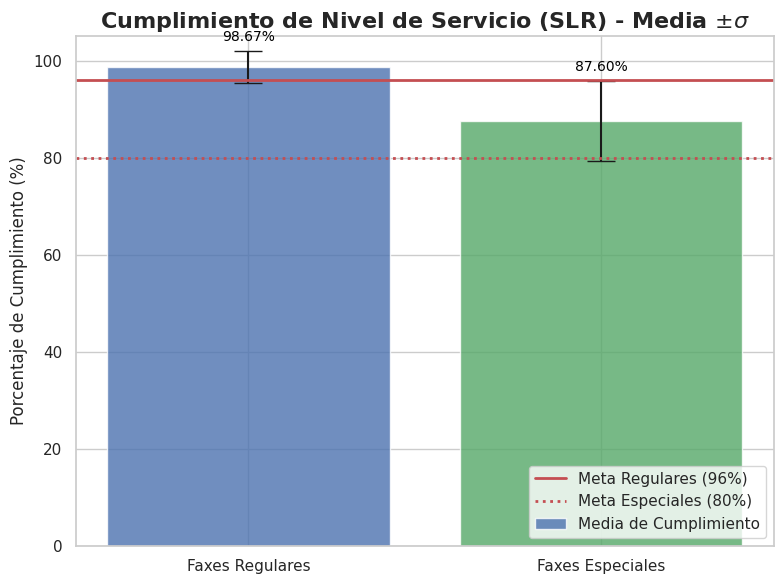

In [ ]:
mean_slr = mean_results[2:] * 100
std_slr = std_results[2:] * 100
categories = ['Faxes Regulares', 'Faxes Especiales']
metas = [96, 80]

# Configuración inicial
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))


ax.bar(
    categories,
    mean_slr,
    yerr=std_slr,
    capsize=10,
    color=['#4C72B0', '#55A868'],
    alpha=0.8,
    label='Media de Cumplimiento'
)


ax.axhline(metas[0], color='r', linestyle='-', linewidth=2, label=f'Meta Regulares ({metas[0]}%)')
ax.axhline(metas[1], color='r', linestyle=':', linewidth=2, label=f'Meta Especiales ({metas[1]}%)')


ax.set_title('Cumplimiento de Nivel de Servicio (SLR) - Media $\pm \sigma$', fontsize=16, fontweight='bold')
ax.set_ylabel('Porcentaje de Cumplimiento (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc='lower right')


for i, mean_val in enumerate(mean_slr):
    ax.text(i, mean_val + std_slr[i] + 2, f'{mean_val:.2f}%', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Esta es la visualización clave para justificar la robustez de la política. Usaremos el Intervalo de Confianza del 95% (IC 95%), que se calcula como:$$\text{IC 95%} = \text{Media} \pm 1.96 \times \frac{\sigma}{\sqrt{N}}$$Donde $N$ es el número de réplicas (100).

Si se repitiera
 esta simulación un número infinito de veces, ¿dónde caería la media real del sistema el 95% de las veces?"


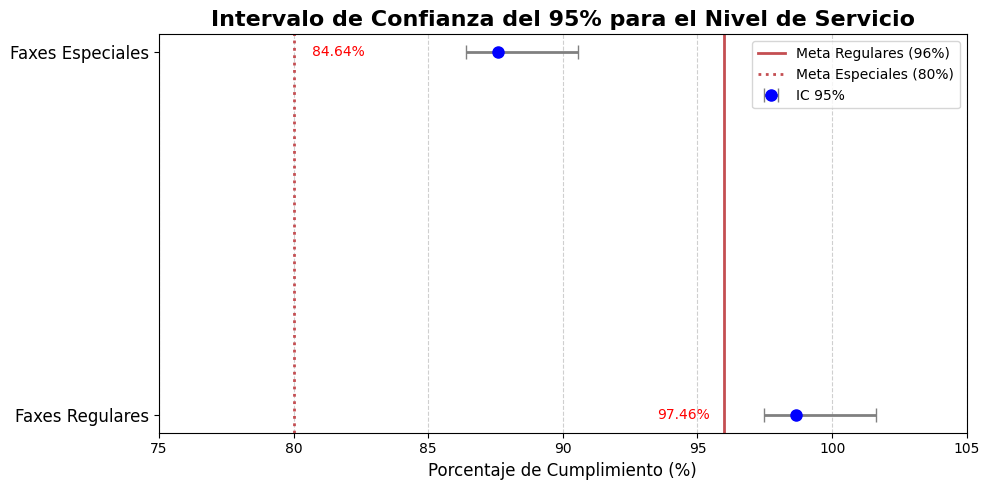

In [ ]:
N = 30
Z_SCORE_95 = 1.96 # Valor Z para un IC del 95% (para N>30, se usaría t-score para N=10)

# Calculamos el error estándar (SE)
se_slr = std_results[2:] / np.sqrt(N)

# Calculamos el margen de error (ME) para el IC 95%
margin_of_error = Z_SCORE_95 * se_slr * 100 # Multiplicado por 100 para porcentaje

# Límites del Intervalo de Confianza (en porcentaje)
ic_lower = (mean_results[2:] * 100) - margin_of_error
ic_upper = (mean_results[2:] * 100) + margin_of_error
ic_yerr = margin_of_error # La longitud de la barra de error es el ME

categories = ['Faxes Regulares', 'Faxes Especiales']
metas = [96, 80]
y_pos = np.arange(len(categories))

# Configuración inicial
plt.style.use('default') # Usamos el estilo por defecto para el rigor científico
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Diagrama de Puntos y Líneas de Error (Interval Plot)
# Nota: Graficamos el error bidireccional (dos veces el margen de error)
# El 'xerr' debe ser un array con el valor del margen de error para cada lado
ax.errorbar(
    mean_results[2:] * 100, # La media en el eje X
    y_pos,                   # La posición de la categoría en el eje Y
    xerr=ic_yerr.reshape(2, 1), # El error bidireccional
    fmt='o',
    capsize=5,
    color='blue',
    ecolor='gray',
    linewidth=2,
    markersize=8,
    label='IC 95%'
)


ax.axvline(metas[0], color='r', linestyle='-', linewidth=2, label=f'Meta Regulares ({metas[0]}%)')
ax.axvline(metas[1], color='r', linestyle=':', linewidth=2, label=f'Meta Especiales ({metas[1]}%)')


ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=12)
ax.set_xlabel('Porcentaje de Cumplimiento (%)', fontsize=12)
ax.set_title('Intervalo de Confianza del 95% para el Nivel de Servicio', fontsize=16, fontweight='bold')

# Añadir el límite inferior (extremo izquierdo) a la gráfica
for i, lower_val in enumerate(ic_lower):
    ax.text(
        lower_val - 2, # Posición justo a la izquierda del límite inferior
        y_pos[i],
        f'{lower_val:.2f}%',
        va='center',
        ha='right',
        color='red',
        fontsize=10
    )

ax.legend(loc='upper right')
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.set_xlim(min(ic_lower.min() - 5, 75), 105)
plt.tight_layout()
plt.show()